# Naive Bayes modell - Predictive Maintenance

Ebben a notebookban Naive Bayes-alapú klasszifikációs modelleket építünk a predictive maintenance adathalmazra.

A cél a `target` változó előrejelzése, amely azt jelzi, hogy történt-e meghibásodás.

A notebookban két modellt hasonlítunk össze:

- Gaussian Naive Bayes
- Bernoulli Naive Bayes

A modelleket keresztvalidációval értékeljük, majd a végső teljesítményt a külön test adathalmazon mérjük.

## 1. Modell relevanciája és elméleti háttér

A Naive Bayes osztályozó a Bayes-tételen alapul. A modell célja annak meghatározása, hogy az adott bemeneti jellemzők mellett melyik osztály a legvalószínűbb.

A Bayes-logika fő elemei:

- **prior**: az osztály előzetes valószínűsége,
- **likelihood**: annak valószínűsége, hogy az adott jellemzők előfordulnak egy adott osztály mellett,
- **posterior**: az osztály valószínűsége a megfigyelt jellemzők ismeretében.

A Naive Bayes modell "naiv" feltételezése, hogy a jellemzők az osztály ismeretében feltételesen függetlenek egymástól. Ez a gyakorlatban sokszor nem teljesül tökéletesen, de a modell egyszerű, gyors és gyakran jó baseline eredményt ad.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

pd.set_option("display.max_columns", None)

## 2. Train és test adatok beolvasása

A tanító és teszt adathalmazt külön CSV fájlokból olvassuk be. Ezeket a korábbi adat-előkészítési és train-test split lépés során hoztuk létre.

Fontos, hogy a test adathalmazt nem használjuk tanításra, csak a végső modell teljesítményének mérésére.

In [5]:
TRAIN_PATH = Path("../../DataCleaning/train.csv")
TEST_PATH = Path("../../DataCleaning/test.csv")

print("Train fájl létezik:", TRAIN_PATH.exists())
print("Test fájl létezik:", TEST_PATH.exists())

print("Train path:", TRAIN_PATH.resolve())
print("Test path:", TEST_PATH.resolve())

Train fájl létezik: True
Test fájl létezik: True
Train path: C:\Users\topol\Desktop\UNI\2_felev\ml_project\PROJECT\MLBeadando\Codes\DataCleaning\train.csv
Test path: C:\Users\topol\Desktop\UNI\2_felev\ml_project\PROJECT\MLBeadando\Codes\DataCleaning\test.csv


In [6]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train méret:", train_df.shape)
print("Test méret:", test_df.shape)

train_df.head()

Train méret: (8000, 9)
Test méret: (2000, 9)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_L,type_M,target
0,302.0,310.9,1456,47.2,54,8.9,0,1,0
1,297.0,308.3,1399,46.4,132,11.3,0,1,0
2,301.0,311.6,1357,45.6,137,10.6,0,1,0
3,298.9,309.8,1411,56.3,84,10.9,1,0,0
4,297.1,308.5,1733,28.7,50,11.4,1,0,0


In [7]:
test_df.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_L,type_M,target
0,300.5,309.8,1345,62.7,153,9.3,1,0,0
1,303.7,312.4,1513,40.1,135,8.7,1,0,0
2,302.5,311.4,1559,37.6,209,8.9,1,0,0
3,295.6,306.3,1509,35.8,60,10.7,0,0,0
4,300.5,310.0,1358,60.4,102,9.5,0,0,0


## 3. Alapellenőrzések

A modellezés előtt ellenőrizzük:

- a train és test oszlopok egyezését,
- a hiányzó értékek számát,
- a `target` oszlop meglétét,
- a bemeneti változók szerkezetét.

In [8]:
print("Train oszlopok:")
print(train_df.columns.tolist())

print("\nTest oszlopok:")
print(test_df.columns.tolist())

print("\nEgyeznek az oszlopok?")
print(train_df.columns.tolist() == test_df.columns.tolist())

print("\nVan target oszlop a trainben?")
print("target" in train_df.columns)

print("\nVan target oszlop a testben?")
print("target" in test_df.columns)

Train oszlopok:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k', 'type_L', 'type_M', 'target']

Test oszlopok:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k', 'type_L', 'type_M', 'target']

Egyeznek az oszlopok?
True

Van target oszlop a trainben?
True

Van target oszlop a testben?
True


In [9]:
missing_summary = pd.DataFrame({
    "train_missing": train_df.isna().sum(),
    "test_missing": test_df.isna().sum()
})

missing_summary

,train_missing,test_missing
air_temperature_k,0,0
process_temperature_k,0,0
rotational_speed_rpm,0,0
torque_nm,0,0
tool_wear_min,0,0
temperature_difference_k,0,0
type_L,0,0
type_M,0,0
target,0,0


## 4. A `type` változó kezelése

Az eredeti `type` kategorikus változó három kategóriát tartalmazott: `L`, `M` és `H`.

Az adat-előkészítés során one-hot encodingot alkalmaztunk `drop_first=True` beállítással. Emiatt csak két dummy változó szerepel az adathalmazban:

- `type_L`
- `type_M`

A harmadik kategória, vagyis a `type_H`, referencia kategóriaként értelmezhető:

- `type_L = 0` és `type_M = 0` → `type_H`
- `type_L = 1` és `type_M = 0` → `type_L`
- `type_L = 0` és `type_M = 1` → `type_M`

Ez nem adatvesztés, hanem a redundancia csökkentése.

In [10]:
type_columns = [col for col in train_df.columns if col.startswith("type_")]

print("Type dummy oszlopok:", type_columns)

if "type_L" in train_df.columns and "type_M" in train_df.columns:
    print("A type_L és type_M oszlopok megtalálhatók.")
else:
    print("Figyelem: valamelyik type dummy oszlop hiányzik.")

Type dummy oszlopok: ['type_L', 'type_M']
A type_L és type_M oszlopok megtalálhatók.


## 5. Magyarázó változók és célváltozó szétválasztása

A `target` oszlop a célváltozó, ezt szeretnénk előrejelezni.

A többi oszlop lesz a modell bemeneti változója.

In [11]:
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

print("X_train méret:", X_train.shape)
print("y_train méret:", y_train.shape)

print("X_test méret:", X_test.shape)
print("y_test méret:", y_test.shape)

X_train méret: (8000, 8)
y_train méret: (8000,)
X_test méret: (2000, 8)
y_test méret: (2000,)


## 6. Osztályeloszlás ellenőrzése

A predictive maintenance adathalmaz eredetileg erősen kiegyensúlyozatlan. A meghibásodás nélküli esetek jelentik a többségi osztályt, míg a meghibásodások ritkábbak.

Ezért a modellértékelés során az accuracy mellett kiemelten figyelünk a precision, recall, F1-score és ROC-AUC értékekre is.

In [12]:
def target_distribution_summary(y, name):
    counts = y.value_counts().sort_index()
    ratios = y.value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "dataset": name,
        "count": counts,
        "ratio_percent": ratios.round(2)
    })
    
    return summary

In [13]:
train_target_summary = target_distribution_summary(y_train, "train")
test_target_summary = target_distribution_summary(y_test, "test")

target_summary = pd.concat([train_target_summary, test_target_summary])

target_summary

,dataset,count,ratio_percent
target,,,
0,train,7729,96.61
1,train,271,3.39
0,test,1932,96.60
1,test,68,3.40


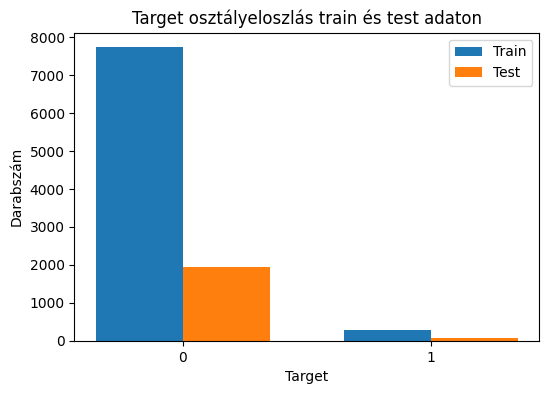

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

x = np.arange(len(train_counts.index))
width = 0.35

ax.bar(x - width/2, train_counts.values, width, label="Train")
ax.bar(x + width/2, test_counts.values, width, label="Test")

ax.set_title("Target osztályeloszlás train és test adaton")
ax.set_xlabel("Target")
ax.set_ylabel("Darabszám")
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index)
ax.legend()

plt.show()

## 7. Modellspecifikus előfeldolgozás

Két Naive Bayes modellt vizsgálunk.

### Gaussian Naive Bayes

A GaussianNB folytonos numerikus változókra alkalmas, mert az egyes jellemzők osztályonkénti eloszlását Gauss-eloszlással közelíti. Emiatt ennél a modellnél nem végzünk külön skálázást.

### Bernoulli Naive Bayes

A BernoulliNB bináris bemeneti változókhoz illeszkedik. Mivel az adathalmazban több folytonos numerikus változó is található, ezekből bináris jellegű változókat kell képezni. A BernoulliNB esetén a folytonos változókat két kvantilis alapú kategóriára bontjuk. Így minden folytonos jellemzőből bináris jellegű, one-hot kódolt változók keletkeznek. Ez lehetővé teszi a BernoulliNB alkalmazását, ugyanakkor információvesztéssel járhat a GaussianNB-hez képest.

In [15]:
binary_columns = []

for col in X_train.columns:
    unique_values = set(X_train[col].dropna().unique())
    if unique_values.issubset({0, 1}):
        binary_columns.append(col)

continuous_columns = [col for col in X_train.columns if col not in binary_columns]

print("Bináris oszlopok:")
print(binary_columns)

print("\nFolytonos/numerikus oszlopok:")
print(continuous_columns)

Bináris oszlopok:
['type_L', 'type_M']

Folytonos/numerikus oszlopok:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k']


## 8. Pipeline-ok létrehozása

A két modellhez külön pipeline-t hozunk létre.

- A GaussianNB közvetlenül a numerikus változókon tanul.
- A BernoulliNB előtt a folytonos változókat bináris kategóriákra alakítjuk, míg a már eleve bináris dummy változókat változatlanul hagyjuk.

In [16]:
gaussian_nb_pipeline = Pipeline([
    ("model", GaussianNB())
])

bernoulli_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous_binning",
            KBinsDiscretizer(
                n_bins=2,
                encode="onehot-dense",
                strategy="quantile"
            ),
            continuous_columns
        ),
        (
            "binary_passthrough",
            "passthrough",
            binary_columns
        )
    ]
)

bernoulli_nb_pipeline = Pipeline([
    ("preprocessor", bernoulli_preprocessor),
    ("model", BernoulliNB(alpha=1.0))
])

models = {
    "GaussianNB": gaussian_nb_pipeline,
    "BernoulliNB": bernoulli_nb_pipeline
}

## 9. Keresztvalidáció beállítása

A modellek összehasonlításához 5-szörös Stratified K-Fold keresztvalidációt használunk.

A stratifikált felosztás azért fontos, mert a célváltozó kiegyensúlyozatlan, és így minden foldban hasonló marad az osztályarány.

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 10. Modell tanítása keresztvalidációval

A keresztvalidáció során a modelleket csak a train adaton értékeljük. A test adatot továbbra sem használjuk, azt csak a végső kiértékelésnél vesszük elő.

In [19]:
cv_results = []

for_model_details = {}

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    for_model_details[model_name] = scores
    
    result_row = {
        "model": model_name
    }
    
    for metric in scoring.keys():
        result_row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result_row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    
    cv_results.append(result_row)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

C:\Users\topol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\topol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warn

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,GaussianNB,0.960250,0.00192,0.377141,0.036527,0.258316,0.026257,0.305306,0.022039,0.893149,0.025263
1,BernoulliNB,0.889375,0.00904,0.132837,0.014934,0.405724,0.030359,0.199877,0.019659,0.748049,0.020308


## 11. Legjobb modell kiválasztása

A modellek összehasonlításánál nem az accuracy az elsődleges szempont, mert az adathalmaz osztályeloszlása kiegyensúlyozatlan.

Elsődleges kiválasztási metrika:

- F1-score

Másodlagos metrikák:

- recall,
- ROC-AUC.

In [20]:
best_model_name = cv_results_df.sort_values(
    by="f1_mean",
    ascending=False
).iloc[0]["model"]

best_model = models[best_model_name]

print(f"A keresztvalidáció alapján kiválasztott legjobb modell: {best_model_name}")

A keresztvalidáció alapján kiválasztott legjobb modell: GaussianNB


## 12. Végső tesztelés a test adathalmazon

A keresztvalidáció után mindkét modellt betanítjuk a teljes train adaton, majd kiértékeljük a test adaton.

Így egyrészt látjuk a kiválasztott legjobb modell teljesítményét, másrészt a két Naive Bayes változatot is össze tudjuk hasonlítani.

In [21]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "average_precision": average_precision_score(y_test, y_proba)
    }
    
    return results, y_pred, y_proba

In [22]:
test_results = {}
predictions = {}
probabilities = {}
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    results, y_pred, y_proba = evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )
    
    test_results[model_name] = results
    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba
    fitted_models[model_name] = model

test_results_df = pd.DataFrame(test_results).T.reset_index(drop=True)

test_results_df

C:\Users\topol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,GaussianNB,0.959,0.294118,0.147059,0.196078,0.889995,0.279089
1,BernoulliNB,0.8835,0.116279,0.367647,0.176678,0.756813,0.089871


In [23]:
for model_name in models.keys():
    print("=" * 80)
    print(f"Classification report - {model_name}")
    print("=" * 80)
    print(classification_report(
        y_test,
        predictions[model_name],
        zero_division=0
    ))

Classification report - GaussianNB
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1932
           1       0.29      0.15      0.20        68

    accuracy                           0.96      2000
   macro avg       0.63      0.57      0.59      2000
weighted avg       0.95      0.96      0.95      2000

Classification report - BernoulliNB
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1932
           1       0.12      0.37      0.18        68

    accuracy                           0.88      2000
   macro avg       0.55      0.63      0.56      2000
weighted avg       0.95      0.88      0.91      2000



## 13. Confusion matrix

A confusion matrix megmutatja, hogy a modell hány esetet sorolt helyesen és helytelenül az egyes osztályokba.

Különösen fontos a false negative esetek száma, mert ezek azok az esetek, amikor a modell nem jelez meghibásodást, pedig valójában történt hiba.

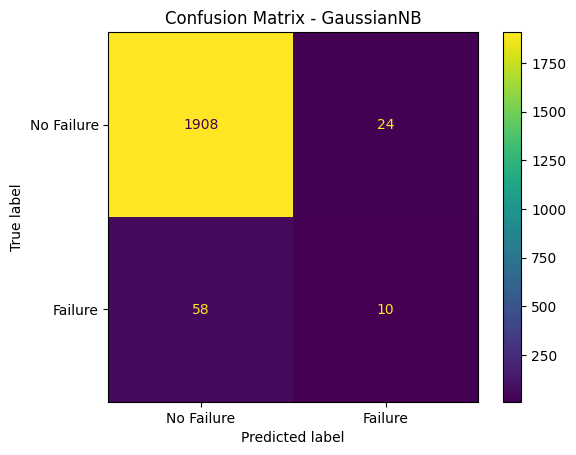

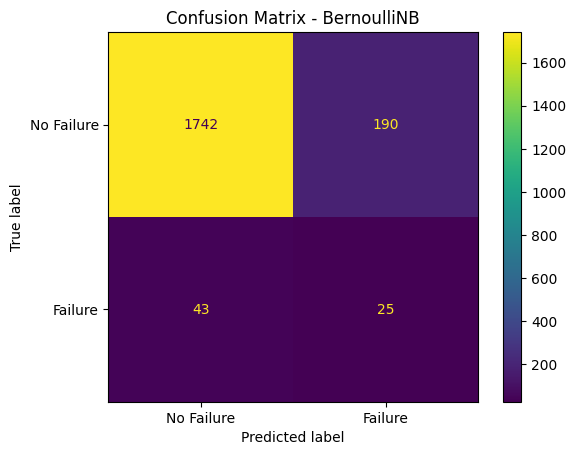

In [24]:
for model_name in models.keys():
    cm = confusion_matrix(y_test, predictions[model_name])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Failure", "Failure"]
    )
    
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

## 14. ROC görbe és AUC

A ROC görbe a true positive rate és false positive rate kapcsolatát mutatja különböző küszöbértékek mellett.

A ROC-AUC érték azt fejezi ki, hogy a modell mennyire jól különíti el a két osztályt.

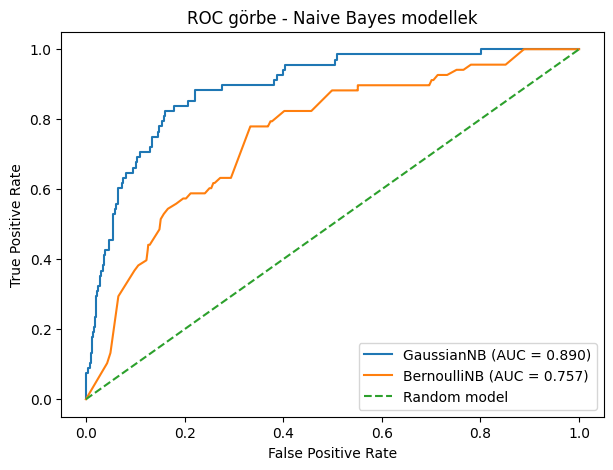

In [25]:
plt.figure(figsize=(7, 5))

for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    auc_value = roc_auc_score(y_test, probabilities[model_name])
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.title("ROC görbe - Naive Bayes modellek")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 15. Precision-Recall görbe

Kiegyensúlyozatlan osztályeloszlás esetén a Precision-Recall görbe különösen hasznos, mert jobban fókuszál a pozitív, ritkább osztály felismerésére.

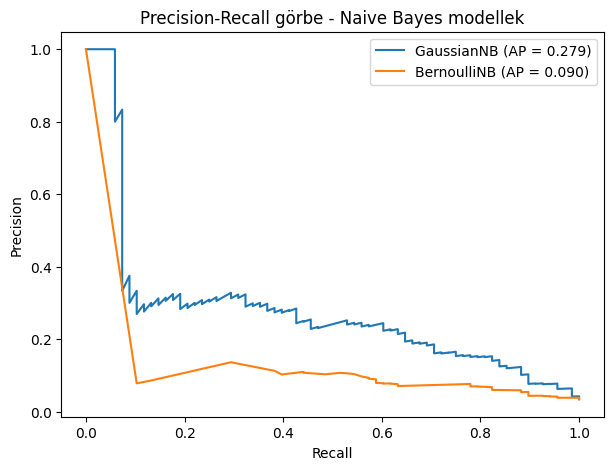

In [26]:
plt.figure(figsize=(7, 5))

for model_name in models.keys():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities[model_name]
    )
    
    ap_value = average_precision_score(
        y_test,
        probabilities[model_name]
    )
    
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_value:.3f})")

plt.title("Precision-Recall görbe - Naive Bayes modellek")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## 16. Prediktált valószínűségek eloszlása

A következő ábra azt mutatja meg, hogy a modellek milyen valószínűségeket rendelnek a pozitív osztályhoz (`target = 1`).

Ez segít megérteni, hogy a modell mennyire magabiztos a meghibásodás előrejelzésében.

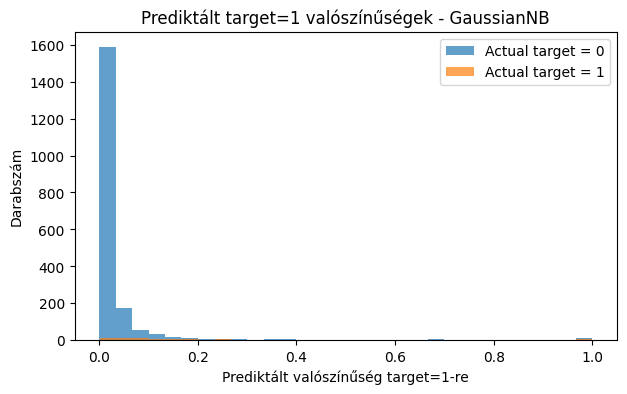

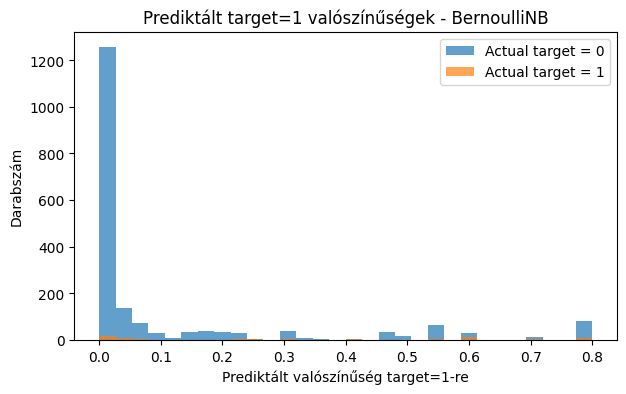

In [27]:
for model_name in models.keys():
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        probabilities[model_name][y_test == 0],
        bins=30,
        alpha=0.7,
        label="Actual target = 0"
    )
    
    plt.hist(
        probabilities[model_name][y_test == 1],
        bins=30,
        alpha=0.7,
        label="Actual target = 1"
    )
    
    plt.title(f"Prediktált target=1 valószínűségek - {model_name}")
    plt.xlabel("Prediktált valószínűség target=1-re")
    plt.ylabel("Darabszám")
    plt.legend()
    plt.show()

## 17. Naive Bayes modellek finomhangolása

Az alap GaussianNB és BernoulliNB modellek után megvizsgáljuk, hogy néhány egyszerű hiperparaméter módosításával javítható-e a teljesítmény.

A cél nem egy túlkomplex tuning folyamat létrehozása, hanem annak ellenőrzése, hogy a Naive Bayes modellek teljesítménye javítható-e főleg F1-score, recall és precision szempontból.

A tuningot kizárólag a train adaton végezzük keresztvalidációval. A test adatot továbbra is csak a végső értékeléshez használjuk.

In [29]:
from sklearn.model_selection import GridSearchCV, cross_val_predict

## 18. Hiperparaméter-tuning GridSearchCV-vel

A GridSearchCV több lehetséges paraméterkombinációt próbál ki, majd keresztvalidáció alapján kiválasztja a legjobb beállítást.

A kiválasztás fő metrikája az F1-score, mert az adathalmaz kiegyensúlyozatlan, így az accuracy önmagában félrevezető lehet.

In [30]:
gaussian_param_grid = {
    "model__var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}

In [31]:
bernoulli_param_grid = {
    "preprocessor__continuous_binning__n_bins": [2, 3, 4],
    "preprocessor__continuous_binning__strategy": ["quantile", "uniform"],
    "model__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

A két modellhez külön paraméterrácsot rendelünk, majd ugyanazzal a StratifiedKFold keresztvalidációval futtatjuk őket.

In [32]:
tuning_configs = {
    "GaussianNB_tuned": {
        "pipeline": gaussian_nb_pipeline,
        "param_grid": gaussian_param_grid
    },
    "BernoulliNB_tuned": {
        "pipeline": bernoulli_nb_pipeline,
        "param_grid": bernoulli_param_grid
    }
}

In [33]:
grid_search_results = []
best_tuned_models = {}

for model_name, config in tuning_configs.items():
    print(f"GridSearch futtatása: {model_name}")
    
    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    
    grid_search.fit(X_train, y_train)
    
    best_tuned_models[model_name] = grid_search.best_estimator_
    
    grid_search_results.append({
        "model": model_name,
        "best_f1_cv": grid_search.best_score_,
        "best_params": grid_search.best_params_
    })

grid_search_results_df = pd.DataFrame(grid_search_results)

grid_search_results_df

GridSearch futtatása: GaussianNB_tuned
GridSearch futtatása: BernoulliNB_tuned


,model,best_f1_cv,best_params
0,GaussianNB_tuned,0.305951,{'model__var_smoothing': 1e-08}
1,BernoulliNB_tuned,0.380891,"{'model__alpha': 0.1, 'preprocessor__continuou..."


## 19. Tuningolt modellek keresztvalidációs eredményei

A GridSearchCV eredményei alapján látható, hogy melyik paraméterkombináció adta a legjobb F1-score értéket a train adaton végzett keresztvalidáció során.

In [34]:
for _, row in grid_search_results_df.iterrows():
    print("=" * 80)
    print(row["model"])
    print("Legjobb CV F1-score:", round(row["best_f1_cv"], 4))
    print("Legjobb paraméterek:")
    print(row["best_params"])

GaussianNB_tuned
Legjobb CV F1-score: 0.306
Legjobb paraméterek:
{'model__var_smoothing': 1e-08}
BernoulliNB_tuned
Legjobb CV F1-score: 0.3809
Legjobb paraméterek:
{'model__alpha': 0.1, 'preprocessor__continuous_binning__n_bins': 4, 'preprocessor__continuous_binning__strategy': 'uniform'}


## 20. Tuningolt modellek végső tesztelése

A legjobb paraméterek kiválasztása után a tuningolt modelleket a teljes train adaton tanítjuk, majd a test adathalmazon értékeljük.

Így össze tudjuk hasonlítani az alapmodellek és a finomhangolt modellek teljesítményét.

In [35]:
tuned_test_results = {}
tuned_predictions = {}
tuned_probabilities = {}

for model_name, model in best_tuned_models.items():
    model.fit(X_train, y_train)
    
    results, y_pred, y_proba = evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )
    
    tuned_test_results[model_name] = results
    tuned_predictions[model_name] = y_pred
    tuned_probabilities[model_name] = y_proba

tuned_test_results_df = pd.DataFrame(tuned_test_results).T.reset_index(drop=True)

tuned_test_results_df.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,GaussianNB_tuned,0.959,0.294118,0.147059,0.196078,0.890033,0.279152
1,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709


In [36]:
comparison_results_df = pd.concat(
    [
        test_results_df.assign(version="baseline"),
        tuned_test_results_df.assign(version="tuned")
    ],
    ignore_index=True
)

comparison_results_df = comparison_results_df[
    [
        "version",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision"
    ]
]

comparison_results_df.round(4)

,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,baseline,GaussianNB,0.959,0.294118,0.147059,0.196078,0.889995,0.279089
1,baseline,BernoulliNB,0.8835,0.116279,0.367647,0.176678,0.756813,0.089871
2,tuned,GaussianNB_tuned,0.959,0.294118,0.147059,0.196078,0.890033,0.279152
3,tuned,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709


## 21. Küszöbérték finomhangolása

A klasszifikációs modellek alapértelmezetten általában 0,5-ös küszöbértékkel döntenek:

- ha `P(target=1) >= 0.5`, akkor a predikció `1`,
- különben a predikció `0`.

Kiegyensúlyozatlan adathalmaz esetén ez a küszöb túl szigorú lehet, ezért érdemes megvizsgálni, hogy alacsonyabb vagy magasabb threshold mellett hogyan változik a precision, recall és F1-score.

A threshold kiválasztását a train adaton belüli keresztvalidációs predikciók alapján végezzük, nem a test adaton.

In [38]:
best_tuned_model_name = grid_search_results_df.sort_values(
    by="best_f1_cv",
    ascending=False
).iloc[0]["model"]

best_tuned_model = best_tuned_models[best_tuned_model_name]

print(f"A CV F1-score alapján legjobb tuningolt modell: {best_tuned_model_name}")

A CV F1-score alapján legjobb tuningolt modell: BernoulliNB_tuned


In [39]:
oof_proba = cross_val_predict(
    best_tuned_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_proba[:10]

array([2.06758610e-02, 2.16660590e-03, 1.51325513e-02, 2.20577922e-02,
       3.76228766e-05, 1.97914645e-05, 1.44140512e-02, 3.77255629e-03,
       1.57599249e-03, 3.83988764e-03])

In [40]:
threshold_values = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in threshold_values:
    y_pred_threshold = (oof_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_train, y_pred_threshold, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
24,0.29,0.317121,0.601476,0.415287
26,0.31,0.328976,0.557196,0.413699
25,0.30,0.319192,0.583026,0.412533
27,0.32,0.331050,0.535055,0.409027
28,0.33,0.334118,0.523985,0.408046
23,0.28,0.304745,0.616236,0.407814
40,0.45,0.383117,0.435424,0.407599
31,0.36,0.345361,0.494465,0.406677
43,0.48,0.409774,0.402214,0.405959
30,0.35,0.340000,0.501845,0.405365


In [41]:
best_threshold_row = threshold_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]

print("Legjobb threshold F1-score alapján:")
print(best_threshold_row)

Legjobb threshold F1-score alapján:
threshold    0.290000
precision    0.317121
recall       0.601476
f1_score     0.415287
Name: 24, dtype: float64


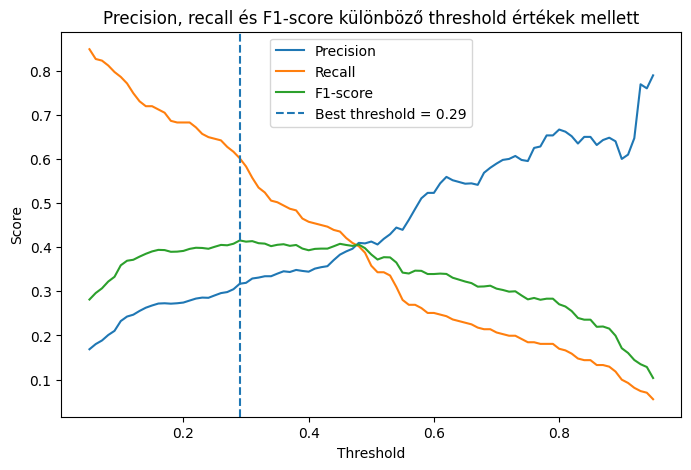

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    label="F1-score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.title("Precision, recall és F1-score különböző threshold értékek mellett")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 22. Végső tesztelés optimalizált threshold mellett

A train adaton keresztvalidációval kiválasztott thresholdot ezután a test adaton alkalmazzuk.

Ezzel megvizsgáljuk, hogy a küszöbérték módosítása javítja-e a modell F1-score vagy recall értékét az alap 0,5-ös döntési küszöbhöz képest.

In [43]:
best_tuned_model.fit(X_train, y_train)

test_proba_best_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

test_pred_default_threshold = (test_proba_best_tuned >= 0.5).astype(int)
test_pred_optimized_threshold = (test_proba_best_tuned >= best_threshold).astype(int)

In [44]:
threshold_comparison_df = pd.DataFrame([
    {
        "model": best_tuned_model_name,
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        "accuracy": accuracy_score(y_test, test_pred_default_threshold),
        "precision": precision_score(y_test, test_pred_default_threshold, zero_division=0),
        "recall": recall_score(y_test, test_pred_default_threshold, zero_division=0),
        "f1_score": f1_score(y_test, test_pred_default_threshold, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_proba_best_tuned),
        "average_precision": average_precision_score(y_test, test_proba_best_tuned)
    },
    {
        "model": best_tuned_model_name,
        "threshold_type": "optimized",
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_test, test_pred_optimized_threshold),
        "precision": precision_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "recall": recall_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "f1_score": f1_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_proba_best_tuned),
        "average_precision": average_precision_score(y_test, test_proba_best_tuned)
    }
])

threshold_comparison_df.round(4)

,model,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,BernoulliNB_tuned,default_0.5,0.50,0.9535,0.3377,0.3824,0.3586,0.8907,0.3047
1,BernoulliNB_tuned,optimized,0.29,0.9430,0.3231,0.6176,0.4242,0.8907,0.3047


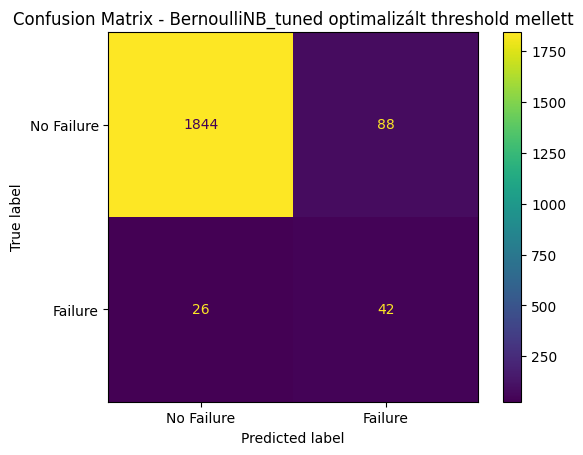

In [45]:
cm_optimized = confusion_matrix(
    y_test,
    test_pred_optimized_threshold
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["No Failure", "Failure"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_tuned_model_name} optimalizált threshold mellett")
plt.show()

In [46]:
all_naive_bayes_results_df = pd.concat(
    [
        comparison_results_df,
        threshold_comparison_df.assign(version="threshold_tuned")
    ],
    ignore_index=True
)

all_naive_bayes_results_df.round(4)

,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,threshold_type,threshold
0,baseline,GaussianNB,0.959,0.294118,0.147059,0.196078,0.889995,0.279089,NaN,NaN
1,baseline,BernoulliNB,0.8835,0.116279,0.367647,0.176678,0.756813,0.089871,NaN,NaN
2,tuned,GaussianNB_tuned,0.959,0.294118,0.147059,0.196078,0.890033,0.279152,NaN,NaN
3,tuned,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709,NaN,NaN
4,threshold_tuned,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709,default_0.5,0.50
5,threshold_tuned,BernoulliNB_tuned,0.943,0.323077,0.617647,0.424242,0.890733,0.304709,optimized,0.29


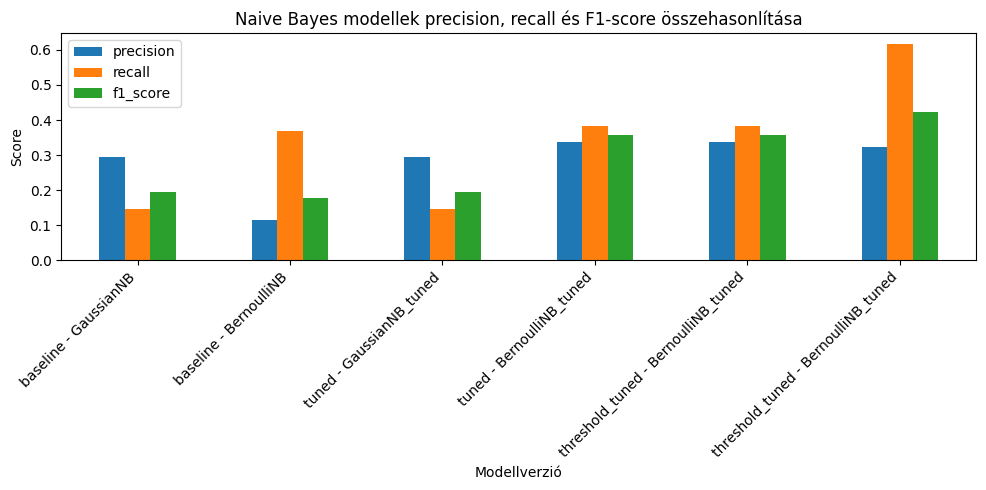

In [48]:
plot_df = all_naive_bayes_results_df.copy()

plot_df["label"] = plot_df["version"] + " - " + plot_df["model"]

plot_metrics = ["precision", "recall", "f1_score"]

plot_df.set_index("label")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Naive Bayes modellek precision, recall és F1-score összehasonlítása")
plt.xlabel("Modellverzió")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Tuning eredmények rövid értelmezése

A hiperparaméter-tuning célja annak vizsgálata volt, hogy a GaussianNB és BernoulliNB modellek teljesítménye javítható-e néhány egyszerű paraméter módosításával.

A GaussianNB esetében a `var_smoothing` paramétert vizsgáltuk, amely a varianciabecslés numerikus stabilitását befolyásolja.

A BernoulliNB esetében az `alpha` Laplace-simítási paramétert, valamint a folytonos változók diszkretizálásának beállításait vizsgáltuk.

Emellett threshold tuningot is alkalmaztunk a legjobb tuningolt modellre. Ennek célja az volt, hogy megvizsgáljuk, javítható-e a recall vagy az F1-score az alapértelmezett 0,5-ös döntési küszöbhöz képest.

A végső modell kiválasztásánál továbbra sem az accuracyt tekintjük elsődleges szempontnak, hanem az F1-score, recall és precision értékeket, mivel az adathalmaz erősen kiegyensúlyozatlan.

A tuning eredményei alapján a BernoulliNB jelentősen javult az alapbeállításokhoz képest. A legjobb beállításnál a folytonos változókat 4 egyenletes intervallumra bontottuk, és az `alpha = 0.1` Laplace-simítási érték bizonyult a legjobbnak.

Ez arra utal, hogy a BernoulliNB számára a folytonos szenzorváltozók egyszerű bináris bontása helyett a több kategóriás diszkretizálás informatívabb bemenetet adott.

A threshold tuning során az alapértelmezett 0,5-ös küszöb helyett a 0,29-es threshold adta a legjobb F1-score-t a keresztvalidációs predikciók alapján. Ez alacsonyabb küszöböt jelent, tehát a modell könnyebben sorol egy esetet meghibásodásnak. Ennek hatására a recall jelentősen nőtt, miközben a precision csak mérsékelten csökkent.

Fontos megjegyezni, hogy a threshold módosítása nem változtatja meg a modell által becsült valószínűségek sorrendjét, ezért a ROC-AUC és az average precision érték változatlan marad. A threshold tuning a végső 0/1 osztálydöntést módosítja, így elsősorban a precision, recall és F1-score értékekre van hatással.

## 24. Eredmények mentése

A Naive Bayes modellek eredményeit CSV fájlba mentjük, hogy később a teljes modell-összehasonlítás során is felhasználhatók legyenek.

In [47]:
UPDATED_RESULTS_PATH = Path("naive_bayes_results_tuned.csv")

all_naive_bayes_results_df.to_csv(UPDATED_RESULTS_PATH, index=False)

print(f"Frissített Naive Bayes eredmények mentve ide: {UPDATED_RESULTS_PATH.resolve()}")

Frissített Naive Bayes eredmények mentve ide: C:\Users\topol\Desktop\UNI\2_felev\ml_project\PROJECT\MLBeadando\Codes\Models\Naive\naive_bayes_results_tuned.csv


In [ ]:
"""RESULTS_PATH = Path("naive_bayes_results.csv")

test_results_df.to_csv(RESULTS_PATH, index=False)

print(f"Eredmények mentve ide: {RESULTS_PATH.resolve()}")"""

Eredmények mentve ide: C:\Users\topol\Desktop\UNI\2_felev\ml_project\PROJECT\MLBeadando\Codes\Models\Naive\naive_bayes_results.csv


## 25. Rövid eredményértelmezés

Az alap Naive Bayes modellek közül kezdetben a GaussianNB teljesített jobban F1-score alapján. A test adathalmazon a GaussianNB accuracy értéke 0,959, F1-score értéke 0,196, ROC-AUC értéke pedig körülbelül 0,890 lett.

A magas accuracy azonban az osztályeloszlás miatt félrevezető lehet, mivel a meghibásodás nélküli esetek jelentik a többségi osztályt. Emiatt a modellértékelésben nagyobb hangsúlyt kapott a precision, recall és F1-score.

A hiperparaméter-tuning után a BernoulliNB teljesítménye jelentősen javult. A legjobb BernoulliNB beállítás `alpha = 0.1`, `n_bins = 4` és `strategy = uniform` volt. Ezzel a modell test adaton 0,359 körüli F1-score-t ért el, ami jelentős javulás az alap BernoulliNB és a GaussianNB baseline eredményéhez képest.

A threshold tuning tovább javította az eredményt. A keresztvalidáció alapján kiválasztott optimális threshold 0,29 lett. Ezzel a végső BernoulliNB_tuned modell F1-score értéke 0,424-re, recall értéke pedig 0,618-ra nőtt. Ez azt jelenti, hogy a modell már a valódi meghibásodások jóval nagyobb részét képes felismerni.

A precision érték 0,323 lett, vagyis a modell több hamis pozitív riasztást is ad. Predictive maintenance környezetben ez elfogadható kompromisszum lehet, ha a cél a meghibásodások minél nagyobb arányú felismerése.

Összességében a végső Naive Bayes modellként a threshold-tuned BernoulliNB tekinthető a legerősebb megoldásnak, mivel ez adta a legjobb F1-score-t és a legmagasabb recall értéket.